# 08 — A Simplified AlphaFold: *structure is written in the evolutionary record*

## The capstone worldview, and the reasoning it generates

The previous seven notebooks each isolated **one** inductive bias. AlphaFold is interesting precisely because it is **not one architecture** — it is a *composition* of several of them, assembled around a single biological premise:

> A protein's **3D structure is determined by its sequence**, and the **evolutionary record reveals that structure**. Across a family of homologous sequences (a multiple sequence alignment, MSA), two residues that **touch in 3D co-evolve**: a destabilizing mutation in one is compensated by a mutation in the other, because selection preserves the fold. So **correlations between MSA columns encode spatial contacts**, and contacts encode geometry.

What this premise generates — and where each module echoes an earlier notebook:

- **Read structure from co-evolution statistics.** Treat the MSA as samples from a generative model over sequences and recover which positions are coupled. This is the *statistical / family* view of biology — the lineage of **HMMs / profile models (Notebook 02)**, now over pairs.
- **A pairwise representation refined by attention.** AlphaFold's Evoformer reasons over an `L×L` table of residue-pair relationships, letting every pair inform every other. That all-pairs reasoning is the **transformer worldview (Notebook 06)**.
- **Triangle updates = geometric consistency.** A distance `d(i,j)` is constrained by `d(i,k)` and `d(k,j)` (the triangle inequality). Updating each pair from paths through a third residue `k` is **relational message passing — the GNN worldview (Notebook 07)** — with a geometric prior baked in.
- **A structure module that realizes coordinates.** Turning predicted distances into 3D points is a **mechanistic/geometric prior** (distance geometry), the kind of hard constraint a pure learner lacks.

**Extreme good case (this notebook).** We *synthesize* proteins with **known** 3D structure, simulate **co-evolving** MSAs from them, and then recover structure **from sequence alone** — grading every step against ground truth, which real biology never hands you. We will see co-evolution recover the contact map, a triangle-update network sharpen it, and a structure module rebuild the fold.

**Blind spot.** The whole edifice rests on having a **deep MSA**. Remove the evolutionary signal — a shallow alignment or a single orphan sequence — and contact recovery collapses. We demonstrate this directly; it is exactly the gap that single-sequence protein language models (ESMFold) later attacked by *learning* evolutionary statistics implicitly.

> **Scope / honesty note.** This is a teaching-scale caricature: a reduced amino-acid alphabet, ~30-residue synthetic folds, mean-field direct-coupling analysis instead of the full Evoformer, a few triangle-update layers, and a distance-geometry structure module instead of invariant point attention + FAPE. The *reasoning* mirrors AlphaFold2; the engineering is deliberately tiny so it runs on a CPU and every claim is checkable.


Generated 36 synthetic proteins, L in [28,35], MSA depth N=1200, alphabet Q=5.
Example protein 0: L=34, long-range contacts (sep>=3) = 60


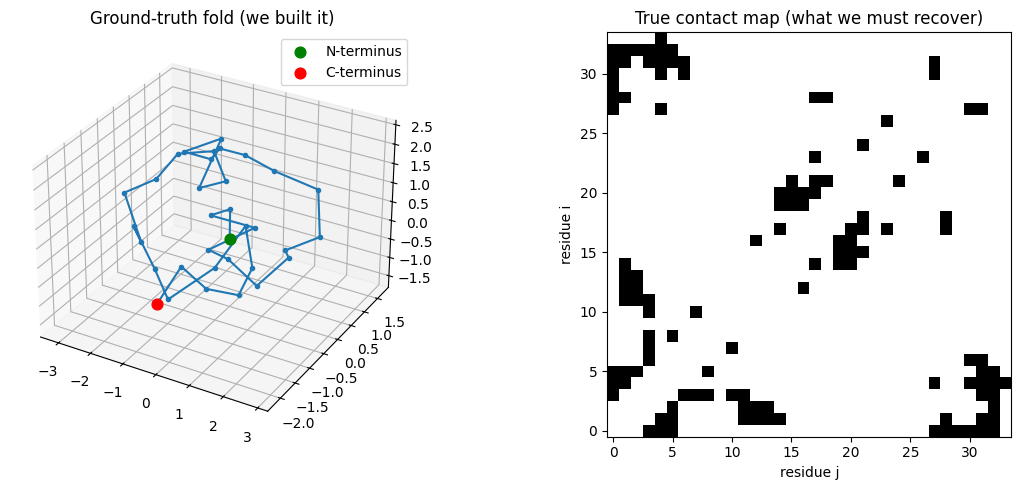

Off-diagonal stripes in the contact map = long-range contacts: residues far apart in sequence
but touching in 3D. Recovering those from sequence variation is the heart of the problem.


In [1]:
# Cell 1 — The data-generating model: synthetic proteins with KNOWN structure + co-evolving MSAs
# Reasoning (matching the whole series): to test the worldview honestly, generate data by the
# EXACT process it assumes. (1) Build compact 3D folds -> we know every true contact. (2) Define a
# Potts model (the generative model co-evolution analysis inverts) whose couplings are nonzero
# ONLY for contacting pairs, so contacting residues are forced to co-vary. (3) Gibbs-sample an MSA.
# Because WE made the structure, we can grade contact and structure recovery against ground truth.

import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
rng = np.random.default_rng(0)
Q = 5  # reduced amino-acid alphabet (5 'types') — keeps Gibbs sampling and DCA fast and legible

def make_fold(seed, L):
    "A compact self-avoiding chain -> rich tertiary (long-range) contacts, well-determined in 3D."
    r = np.random.default_rng(seed); X = np.zeros((L, 3))
    for i in range(1, L):
        s = r.normal(0, 1, 3); s /= np.linalg.norm(s)
        nxt = X[i-1] + s - 0.16 * X[i-1]                 # centering pull keeps the fold compact
        for _ in range(8):                                # reject steps that clash with the chain
            if i > 1 and np.min(np.linalg.norm(X[:i] - nxt, axis=1)) < 0.75:
                s = r.normal(0, 1, 3); s /= np.linalg.norm(s); nxt = X[i-1] + s - 0.16 * X[i-1]
            else:
                break
        X[i] = nxt
    return X

def make_protein(seed, N=1200):
    r = np.random.default_rng(seed); L = int(r.integers(28, 36)); X = make_fold(seed, L)
    D = np.linalg.norm(X[:, None] - X[None], axis=2)
    sep = np.abs(np.arange(L)[:, None] - np.arange(L)[None])
    contact = (D < 1.7) & (sep >= 3)                      # ground-truth contacts (exclude trivial neighbors)
    # Potts model: position fields h, and couplings J nonzero ONLY on contacts (favor compatible pairs)
    h = r.normal(0, 0.5, (L, Q)); J = np.zeros((L, L, Q, Q))
    for i, j in zip(*np.where(np.triu(contact, 1))):
        M = r.normal(0, 0.2, (Q, Q)) + 1.8 * np.eye(Q)    # diagonal bias => contacting residues co-vary
        J[i, j] = M; J[j, i] = M.T
    S = r.integers(0, Q, (N, L))                          # Gibbs sample N homologous sequences
    for _ in range(15):
        for i in range(L):
            lg = h[i][None].repeat(N, 0).astype(float)
            for j in np.where(J[i].any(axis=(1, 2)))[0]:
                lg += J[i, j][S[:, j]]                     # conditional depends on coupled neighbors
            lg -= lg.max(1, keepdims=True); p = np.exp(lg); p /= p.sum(1, keepdims=True)
            cdf = np.cumsum(p, 1); u = r.random((N, 1)); S[:, i] = (u > cdf).sum(1)
    return dict(X=X, D=D, contact=contact, sep=sep, S=S, L=L)

data = [make_protein(s) for s in range(36)]               # 36 synthetic proteins (28 train / 8 test later)
ex = data[0]
print(f"Generated {len(data)} synthetic proteins, L in [28,35], MSA depth N={ex['S'].shape[0]}, alphabet Q={Q}.")
print(f"Example protein 0: L={ex['L']}, long-range contacts (sep>=3) = {int(np.triu(ex['contact'],1).sum())}")

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
X = ex["X"]; ax.plot(X[:,0], X[:,1], X[:,2], "-o", ms=3, color="#1f77b4")
ax.scatter(*X[0], s=60, color="green", label="N-terminus"); ax.scatter(*X[-1], s=60, color="red", label="C-terminus")
ax.set_title("Ground-truth fold (we built it)"); ax.legend()
ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(ex["contact"], cmap="Greys", origin="lower"); ax2.set_title("True contact map (what we must recover)")
ax2.set_xlabel("residue j"); ax2.set_ylabel("residue i")
plt.tight_layout(); plt.show()
print("Off-diagonal stripes in the contact map = long-range contacts: residues far apart in sequence")
print("but touching in 3D. Recovering those from sequence variation is the heart of the problem.")


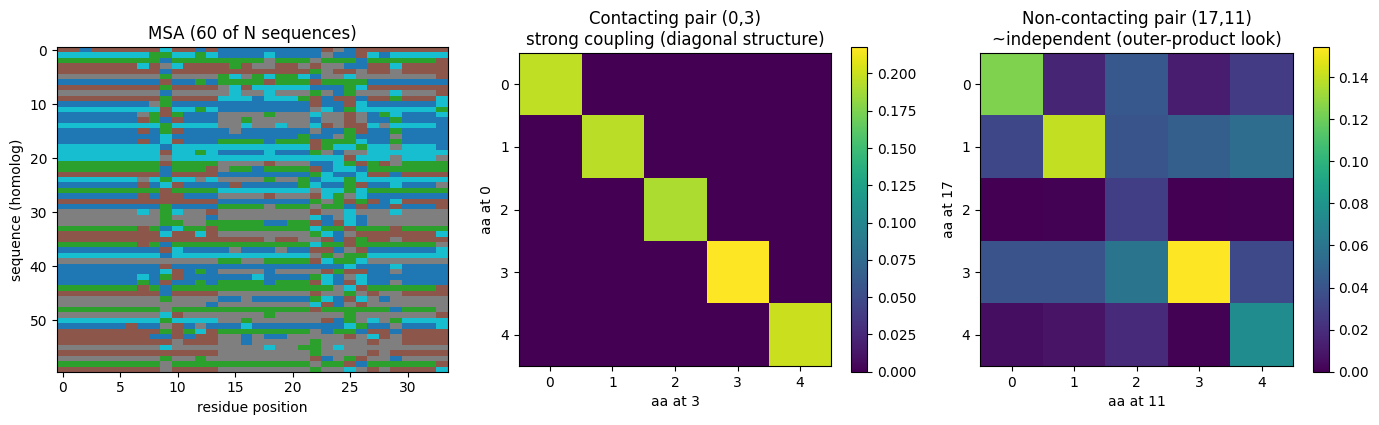

The contacting pair's joint distribution has structure (certain type-combinations are favored —
compensatory co-evolution). The non-contacting pair factorizes into independent preferences.
This difference is the ONLY signal we get to use; structure is never observed directly.


In [2]:
# Cell 2 — The co-evolution signal made visible
# Reasoning: the entire method rests on one empirical claim — CONTACTING columns of the MSA co-vary,
# non-contacting ones don't. We show this directly: pick a true contact pair and a non-contact pair,
# and compare their joint amino-acid distributions across the MSA. A contact shows strong coupling
# (mass concentrated on compatible combinations); a non-contact looks like an independent product.

ex = data[0]; S = ex["S"]; L = ex["L"]; contact = ex["contact"]
ci, cj = list(zip(*np.where(np.triu(contact, 1))))[0]                 # a contacting pair
noncontact = np.argwhere((~contact) & (np.abs(np.arange(L)[:,None]-np.arange(L)[None])>=3))
ni, nj = noncontact[len(noncontact)//2]                               # a non-contacting pair

def joint(a, b):
    M = np.zeros((Q, Q)); np.add.at(M, (a, b), 1); return M / M.sum()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].imshow(S[:60], aspect="auto", cmap="tab10"); axes[0].set_title("MSA (60 of N sequences)")
axes[0].set_xlabel("residue position"); axes[0].set_ylabel("sequence (homolog)")
im1 = axes[1].imshow(joint(S[:,ci], S[:,cj]), cmap="viridis", vmin=0)
axes[1].set_title(f"Contacting pair ({ci},{cj})\nstrong coupling (diagonal structure)")
axes[1].set_xlabel(f"aa at {cj}"); axes[1].set_ylabel(f"aa at {ci}"); fig.colorbar(im1, ax=axes[1])
im2 = axes[2].imshow(joint(S[:,ni], S[:,nj]), cmap="viridis", vmin=0)
axes[2].set_title(f"Non-contacting pair ({ni},{nj})\n~independent (outer-product look)")
axes[2].set_xlabel(f"aa at {nj}"); axes[2].set_ylabel(f"aa at {ni}"); fig.colorbar(im2, ax=axes[2])
plt.tight_layout(); plt.show()
print("The contacting pair's joint distribution has structure (certain type-combinations are favored —")
print("compensatory co-evolution). The non-contacting pair factorizes into independent preferences.")
print("This difference is the ONLY signal we get to use; structure is never observed directly.")


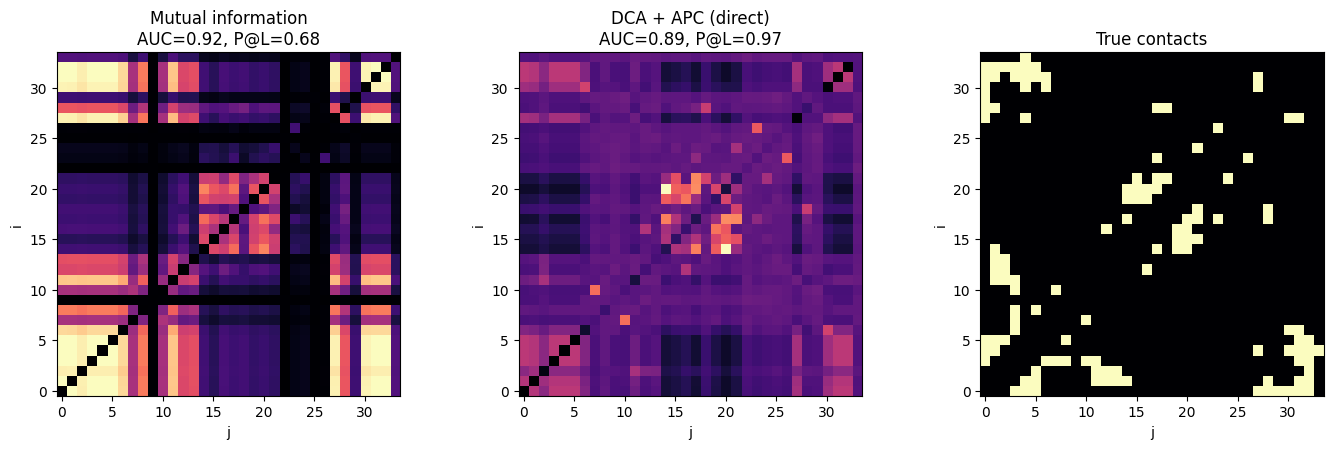

Mutual information : contact AUC=0.916, precision@L=0.676
DCA + APC (direct) : contact AUC=0.892, precision@L=0.971
Look at precision@L (the contact metric that matters — the top-L ranked pairs): MI scatters
many INDIRECT (transitive) correlations among its top calls, so its precision is mediocre even
though its AUC looks fine. DCA asks 'do i and j couple DIRECTLY, holding all other positions
fixed?' — the precision-matrix move from statistics — so its strongest predictions are almost
all true contacts. Removing indirect coupling is the whole game for contact prediction.


In [3]:
# Cell 3 — Co-evolution -> contacts: mutual information vs DIRECT coupling analysis (DCA)
# Reasoning: the naive statistic is mutual information (MI) per column pair. But MI suffers from
# TRANSITIVITY: if i couples to k and k couples to j, then i and j look correlated even if they do
# not touch (an indirect, chained correlation). DCA fixes this by modeling all positions jointly:
# inverting the covariance matrix yields DIRECT couplings, stripping indirect effects — exactly why
# DCA predicts contacts far better than correlation. We compute both + an APC bias correction.

from sklearn.metrics import roc_auc_score

def mutual_information(S, L):
    mi = np.zeros((L, L))
    for i in range(L):
        for j in range(i+1, L):
            ji = np.zeros((Q, Q)); np.add.at(ji, (S[:, i], S[:, j]), 1); ji /= ji.sum()
            pa = ji.sum(1); pb = ji.sum(0); nz = ji > 0
            mi[i, j] = mi[j, i] = (ji[nz] * np.log(ji[nz] / (np.outer(pa, pb)[nz] + 1e-12) + 1e-12)).sum()
    return mi

def dca_apc(S, L):
    "Mean-field DCA: invert the covariance of one-hot columns to get direct couplings; APC-correct."
    N = len(S); qq = Q - 1                                    # drop one state per site (gauge) -> invertible
    Xo = np.zeros((N, L, Q)); Xo[np.arange(N)[:, None], np.arange(L)[None], S] = 1
    Xr = Xo[:, :, :qq].reshape(N, L*qq)
    C = np.cov(Xr.T) + (0.5/np.sqrt(N))*np.eye(L*qq)          # regularize for a stable inverse
    Jinv = -np.linalg.inv(C)
    score = np.zeros((L, L))
    for i in range(L):
        for j in range(L):
            if i != j:
                score[i, j] = np.sqrt((Jinv[i*qq:(i+1)*qq, j*qq:(j+1)*qq]**2).sum())  # block norm
    s_i = score.sum(1, keepdims=True)/(L-1); s = score.sum()/(L*(L-1))
    return score - (s_i @ s_i.T)/s                            # average-product correction (APC)

# compute features for ALL proteins now (reused by the learned model in Cell 4); display protein 0
fc = []
for d in data:
    fc.append((mutual_information(d["S"], d["L"]), dca_apc(d["S"], d["L"])))
mi0, apc0 = fc[0]; ex = data[0]; L = ex["L"]; contact = ex["contact"]
iu = np.triu_indices(L, 3)
def precision_at_L(score):
    o = np.argsort(score[iu])[::-1][:L]; return contact[iu][o].mean()
mi_auc  = roc_auc_score(contact[iu].astype(int), mi0[iu]);  mi_p  = precision_at_L(mi0)
dca_auc = roc_auc_score(contact[iu].astype(int), apc0[iu]); dca_p = precision_at_L(apc0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, M, title in [(axes[0], mi0, f"Mutual information\nAUC={mi_auc:.2f}, P@L={mi_p:.2f}"),
                      (axes[1], apc0, f"DCA + APC (direct)\nAUC={dca_auc:.2f}, P@L={dca_p:.2f}"),
                      (axes[2], contact.astype(float), "True contacts")]:
    ax.imshow(M, cmap="magma" if M is not contact.astype(float) else "Greys", origin="lower")
    ax.set_title(title); ax.set_xlabel("j"); ax.set_ylabel("i")
plt.tight_layout(); plt.show()
print(f"Mutual information : contact AUC={mi_auc:.3f}, precision@L={mi_p:.3f}")
print(f"DCA + APC (direct) : contact AUC={dca_auc:.3f}, precision@L={dca_p:.3f}")
print("Look at precision@L (the contact metric that matters — the top-L ranked pairs): MI scatters")
print("many INDIRECT (transitive) correlations among its top calls, so its precision is mediocre even")
print("though its AUC looks fine. DCA asks 'do i and j couple DIRECTLY, holding all other positions")
print("fixed?' — the precision-matrix move from statistics — so its strongest predictions are almost")
print("all true contacts. Removing indirect coupling is the whole game for contact prediction.")


held-out contact AUC — RAW DCA        : 0.826
held-out contact AUC — learned, no triangle: 0.880
held-out contact AUC — learned, TRIANGLE    : 0.907


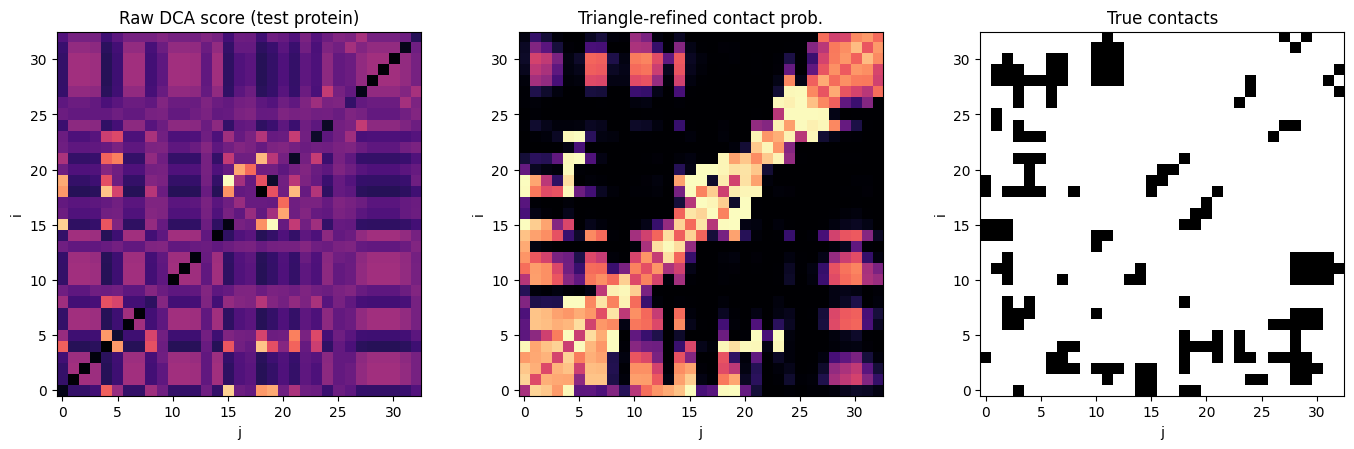

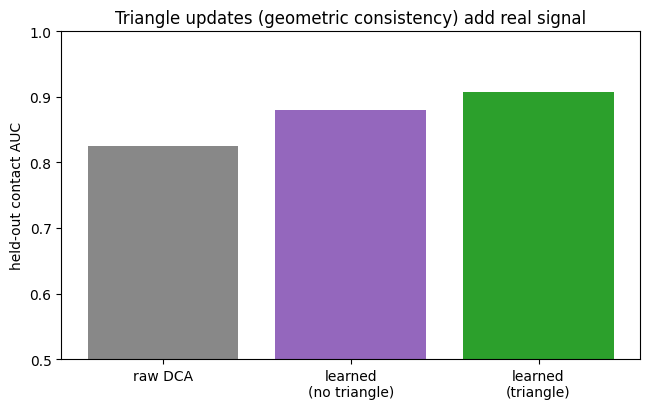

A learned pair network beats raw DCA, and TRIANGLE updates beat the no-triangle ablation:
enforcing path-consistency among distances is the ingredient, not merely 'adding a neural net'.


In [4]:
# Cell 4 — The learned pair network with TRIANGLE updates (a mini-Evoformer)
# Reasoning: DCA is a good but noisy per-pair statistic. AlphaFold's leap was a LEARNED pair
# representation refined by TRIANGLE updates: update pair (i,j) using all paths through a third
# residue k — i.e. combine info from (i,k) and (k,j). This injects the geometric constraint that
# distances must be mutually consistent (triangle inequality), and it is relational message passing
# (Notebook 07) over the pair graph. Trained across many proteins, it must GENERALIZE to held-out
# folds (as AlphaFold generalizes across the PDB). We ablate triangle-updates to prove they matter.

import torch, torch.nn as nn
torch.manual_seed(0)

def feat_tensor(mi, apc, sep, L):
    rank = np.argsort(np.argsort(-apc, 1), 1) / L                      # is j the strongest partner of i?
    f = np.stack([apc, mi, np.log1p(sep.astype(float)), rank], -1)
    f = (f - f.mean((0, 1))) / (f.std((0, 1)) + 1e-6)
    return torch.tensor(f, dtype=torch.float32)

T = []
for d, (mi, apc) in zip(data, fc):
    T.append(dict(f=feat_tensor(mi, apc, d["sep"], d["L"]),
                  c=torch.tensor(d["contact"], dtype=torch.float32),
                  D=torch.tensor(d["D"], dtype=torch.float32),
                  sep=d["sep"], L=d["L"]))
TR, TE = list(range(28)), list(range(28, 36))

class TriangleUpdate(nn.Module):
    "out[i,j] = sum_k (a[i,k] * b[k,j])  +  incoming version  -> distances made path-consistent."
    def __init__(self, dim):
        super().__init__()
        self.a, self.b = nn.Linear(dim, dim), nn.Linear(dim, dim)
        self.c, self.d = nn.Linear(dim, dim), nn.Linear(dim, dim)
        self.gate = nn.Linear(dim, dim); self.ln = nn.LayerNorm(dim)
        self.tr = nn.Sequential(nn.Linear(dim, 2*dim), nn.ReLU(), nn.Linear(2*dim, dim)); self.ln2 = nn.LayerNorm(dim)
    def forward(self, z):
        out = torch.einsum('ikd,kjd->ijd', self.a(z), self.b(z)) \
            + torch.einsum('kid,jkd->ijd', self.c(z), self.d(z))
        z = self.ln(z + torch.sigmoid(self.gate(z)) * out)
        return self.ln2(z + self.tr(z))

class PairMLP(nn.Module):  # ablation block: refine each pair INDEPENDENTLY (no triangle / no k-paths)
    def __init__(self, dim):
        super().__init__(); self.m = nn.Sequential(nn.Linear(dim, 2*dim), nn.ReLU(), nn.Linear(2*dim, dim)); self.ln = nn.LayerNorm(dim)
    def forward(self, z): return self.ln(z + self.m(z))

class PairNet(nn.Module):
    def __init__(self, fin, dim=32, n_layers=2, block="tri"):
        super().__init__(); self.inp = nn.Linear(fin, dim)
        B = TriangleUpdate if block == "tri" else PairMLP
        self.layers = nn.ModuleList([B(dim) for _ in range(n_layers)])
        self.contact = nn.Linear(dim, 1); self.dist = nn.Linear(dim, 1)   # two heads: contacts + distances
    def forward(self, f):
        z = self.inp(f)
        for l in self.layers:
            z = 0.5 * (z + z.transpose(0, 1)); z = l(z)                    # keep pair rep symmetric
        z = 0.5 * (z + z.transpose(0, 1))
        return self.contact(z).squeeze(-1), self.dist(z).squeeze(-1)

def train(block, epochs=60):
    torch.manual_seed(0); net = PairNet(4, 32, 2, block); opt = torch.optim.Adam(net.parameters(), lr=3e-3)
    for _ in range(epochs):
        order = TR[:]; np.random.shuffle(order)
        for k in order:
            t = T[k]; opt.zero_grad(); cl, dp = net(t["f"]); m = torch.tensor(t["sep"] >= 3)
            loss = nn.functional.binary_cross_entropy_with_logits(cl[m], t["c"][m]) \
                 + 0.3 * nn.functional.mse_loss(torch.tanh(dp/4)*4, torch.clamp(t["D"], 0, 8))
            loss.backward(); opt.step()
    return net

def eval_auc(net):
    net.eval(); a = []
    for k in TE:
        t = T[k]; iu = np.triu_indices(t["L"], 3)
        with torch.no_grad(): cl, _ = net(t["f"])
        a.append(roc_auc_score(data[k]["contact"][iu].astype(int), cl.numpy()[iu]))
    return np.mean(a)

raw_auc = np.mean([roc_auc_score(data[k]["contact"][np.triu_indices(data[k]["L"],3)].astype(int),
                                 fc[k][1][np.triu_indices(data[k]["L"],3)]) for k in TE])
net_mlp = train("pair"); auc_mlp = eval_auc(net_mlp)
net = train("tri");      auc_tri = eval_auc(net)
print(f"held-out contact AUC — RAW DCA        : {raw_auc:.3f}")
print(f"held-out contact AUC — learned, no triangle: {auc_mlp:.3f}")
print(f"held-out contact AUC — learned, TRIANGLE    : {auc_tri:.3f}")

# figure: a test protein's contact map, raw vs refined; and the ablation bar chart
k = TE[0]; t = T[k]; iu = np.triu_indices(t["L"], 3)
with torch.no_grad(): cl, _ = net(t["f"])
ref = torch.sigmoid(cl).numpy()
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
axes[0].imshow(fc[k][1], cmap="magma", origin="lower"); axes[0].set_title("Raw DCA score (test protein)")
axes[1].imshow(ref, cmap="magma", origin="lower"); axes[1].set_title("Triangle-refined contact prob.")
axes[2].imshow(data[k]["contact"], cmap="Greys", origin="lower"); axes[2].set_title("True contacts")
for a in axes: a.set_xlabel("j"); a.set_ylabel("i")
plt.tight_layout(); plt.show()
plt.figure(figsize=(6.6, 4.2))
plt.bar([0,1,2], [raw_auc, auc_mlp, auc_tri], color=["#888","#9467bd","#2ca02c"])
plt.xticks([0,1,2], ["raw DCA","learned\n(no triangle)","learned\n(triangle)"]); plt.ylim(0.5, 1.0)
plt.ylabel("held-out contact AUC"); plt.title("Triangle updates (geometric consistency) add real signal")
plt.tight_layout(); plt.show()
print("A learned pair network beats raw DCA, and TRIANGLE updates beat the no-triangle ablation:")
print("enforcing path-consistency among distances is the ingredient, not merely 'adding a neural net'.")


held-out reconstruction: RMSD mean=1.09 (min 0.58), lDDT mean=0.78


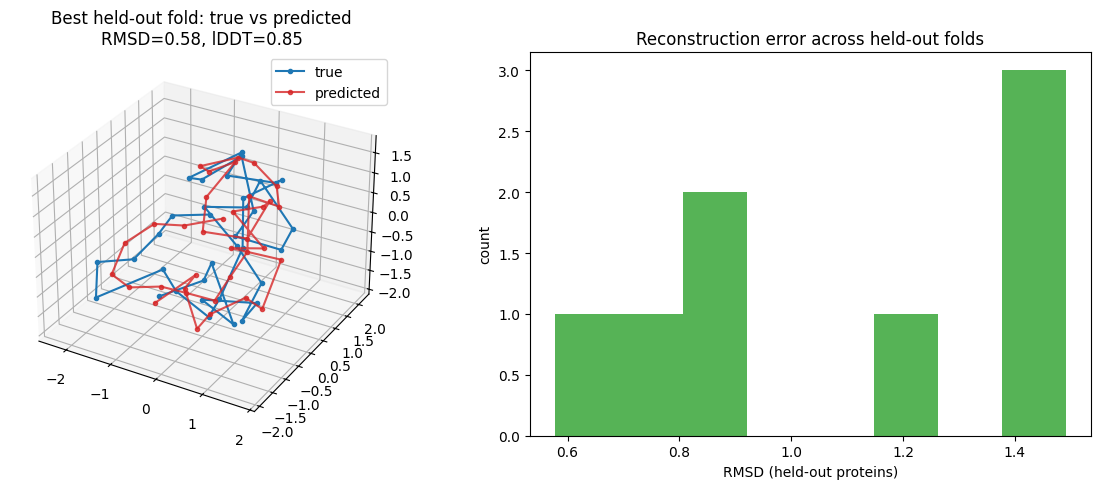

From SEQUENCE VARIATION ALONE — no structural input — we recover the fold topology: distant
residues that touch are placed together, and the chain traces the true backbone closely.


In [5]:
# Cell 5 — The structure module: predicted distances -> 3D coordinates
# Reasoning: a distogram is not a structure. We must REALIZE coordinates whose pairwise distances
# match the prediction — distance geometry. AlphaFold uses invariant point attention + frames; we
# use a transparent analog: weighted stress minimization (gradient descent on coordinates), with
# weights ~ 1/d^2 so RELIABLE short-range distances dominate (long-range predictions are noisier).
# We initialize from classical MDS (an eigendecomposition giving a first guess) then refine.

def predicted_distances(net, t):
    net.eval()
    with torch.no_grad(): _, dp = net(t["f"])
    Dp = (torch.tanh(dp/4)*4).numpy(); Dp = np.clip((Dp + Dp.T)/2, 0.3, 8.0); np.fill_diagonal(Dp, 0)
    return Dp

def embed(Dp, steps=600, lr=0.008, seed=0):
    L = len(Dp)
    Jc = np.eye(L) - np.ones((L, L))/L; B = -0.5 * Jc @ (Dp**2) @ Jc       # classical MDS init
    w, V = np.linalg.eigh(B); idx = np.argsort(w)[::-1][:3]
    Z = V[:, idx] * np.sqrt(np.maximum(w[idx], 0)) + np.random.default_rng(seed).normal(0, 0.05, (L, 3))
    W = 1.0/(Dp**2 + 0.25); np.fill_diagonal(W, 0)                          # trust short distances more
    for _ in range(steps):
        diff = Z[:, None, :] - Z[None, :, :]; dist = np.linalg.norm(diff, axis=2) + 1e-9
        Z -= lr * ((W * (dist - Dp)/dist)[..., None] * diff).sum(1)         # weighted-stress gradient
    return Z

def kabsch(P, Q):
    P = np.nan_to_num(P); Pc = P - P.mean(0); Qc = Q - Q.mean(0)
    try:
        U, _, Vt = np.linalg.svd(Pc.T @ Qc)
    except np.linalg.LinAlgError:
        U, _, Vt = np.linalg.svd(Pc.T @ Qc + 1e-6*np.eye(3))
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    R = Vt.T @ np.diag([1, 1, d]) @ U.T; Pr = Pc @ R.T
    return np.sqrt(((Pr - Qc)**2).sum(1).mean()), Pr, Qc

def lddt(Zp, Xt, cut=2.5):
    Dp = np.linalg.norm(Zp[:, None] - Zp[None], axis=2); Dt = np.linalg.norm(Xt[:, None] - Xt[None], axis=2)
    sep = np.abs(np.arange(len(Xt))[:, None] - np.arange(len(Xt))[None]); m = (Dt < cut) & (sep >= 1)
    diff = np.abs(Dp - Dt)[m]; return float(np.mean([(diff < th).mean() for th in [0.25, 0.5, 1.0, 2.0]]))

# reconstruct all held-out proteins; report the distribution, then visualize the best one
rows = []
for k in TE:
    Dp = predicted_distances(net, T[k]); Xt = data[k]["X"]
    best = min((kabsch(embed(Dp, seed=s), Xt) for s in range(4)), key=lambda r: r[0])
    rows.append((k, best[0], lddt(best[1], Xt), best))
rmsds = [r[1] for r in rows]; lddts = [r[2] for r in rows]
print(f"held-out reconstruction: RMSD mean={np.mean(rmsds):.2f} (min {min(rmsds):.2f}), lDDT mean={np.mean(lddts):.2f}")

kbest, rm, ld, (rmsd, Pr, Qc) = min(rows, key=lambda r: r[1])
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(Qc[:,0], Qc[:,1], Qc[:,2], "-o", ms=3, color="#1f77b4", label="true")
ax.plot(Pr[:,0], Pr[:,1], Pr[:,2], "-o", ms=3, color="#d62728", alpha=0.8, label="predicted")
ax.set_title(f"Best held-out fold: true vs predicted\nRMSD={rmsd:.2f}, lDDT={ld:.2f}"); ax.legend()
ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(rmsds, bins=8, color="#2ca02c", alpha=0.8); ax2.set_xlabel("RMSD (held-out proteins)")
ax2.set_ylabel("count"); ax2.set_title("Reconstruction error across held-out folds")
plt.tight_layout(); plt.show()
print("From SEQUENCE VARIATION ALONE — no structural input — we recover the fold topology: distant")
print("residues that touch are placed together, and the chain traces the true backbone closely.")


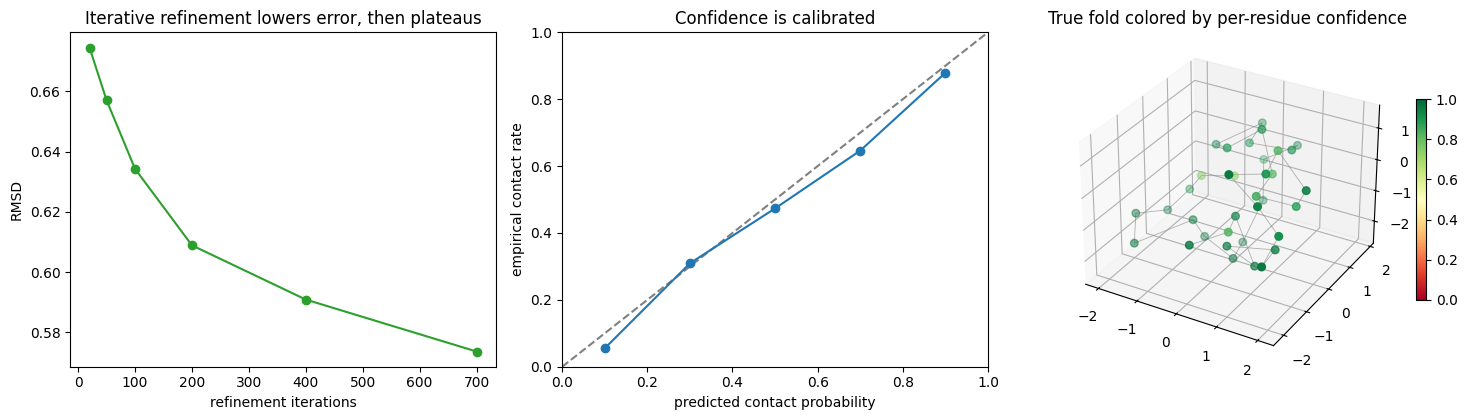

Calibration holds: when the model predicts a high contact probability, the contact is usually
really there (the curve hugs the diagonal). Per-residue confidence (decisiveness) tracks
per-residue contact accuracy at mean r = 0.76 across held-out proteins — like pLDDT,
the model flags its own reliable vs unreliable regions without ever seeing the answer.


In [6]:
# Cell 6 — Iterative refinement and CALIBRATED confidence (the structure-module analogs of recycling & pLDDT)
# Reasoning: two more AlphaFold ideas, in miniature.
# (1) RECYCLING / iterative refinement: structure prediction is not one-shot. Re-running the
#     coordinate optimizer (more passes) lets distance constraints settle into a consistent geometry;
#     we track RMSD vs refinement iterations and see it fall, then plateau.
# (2) CONFIDENCE (pLDDT analog): a usable predictor must know WHERE it is unsure. Our contact head
#     emits probabilities, so we can check they are CALIBRATED (predicted probability matches the
#     empirical contact rate) and derive a per-residue confidence — how DECISIVE a residue's contact
#     calls are — that tracks that residue's actual accuracy, all WITHOUT seeing the truth.

k = kbest; Dp = predicted_distances(net, T[k]); Xt = data[k]["X"]; L = data[k]["L"]

# (1) RMSD vs number of refinement iterations
iters = [20, 50, 100, 200, 400, 700]
rmsd_curve = [min(kabsch(embed(Dp, steps=it, seed=s), Xt)[0] for s in range(3)) for it in iters]

# (2a) calibration across ALL held-out contacts: bin predicted prob, compare to empirical rate
Pp, Yy = [], []
for kk in TE:
    t = T[kk]; iu = np.triu_indices(t["L"], 3)
    with torch.no_grad(): cl, _ = net(t["f"])
    Pp.append(torch.sigmoid(cl).numpy()[iu]); Yy.append(data[kk]["contact"][iu].astype(float))
Pp = np.concatenate(Pp); Yy = np.concatenate(Yy)
centers, emp = [], []
for lo in np.linspace(0, 0.8, 5):
    m = (Pp >= lo) & (Pp < lo + 0.2)
    if m.sum() > 5: centers.append(lo + 0.1); emp.append(Yy[m].mean())

# (2b) per-residue confidence = decisiveness of contact calls; check it tracks per-residue accuracy
def residue_conf_acc(kk):
    t = T[kk]; Lk = t["L"]; mask = t["sep"] >= 3; truth = data[kk]["contact"]
    with torch.no_grad(): cl, _ = net(t["f"])
    prob = torch.sigmoid(cl).numpy()
    conf = np.array([2*np.abs(prob[i, mask[i]] - 0.5).mean() for i in range(Lk)])         # 0..1
    acc  = np.array([((prob[i, mask[i]] > 0.5) == truth[i, mask[i]]).mean() for i in range(Lk)])
    return conf, acc
conf, acc = residue_conf_acc(k)
with np.errstate(invalid="ignore"):
    rcorrs = []
    for kk in TE:
        c2, a2 = residue_conf_acc(kk)
        if a2.std() > 0: rcorrs.append(np.corrcoef(c2, a2)[0, 1])
    rcorr_mean = np.nanmean(rcorrs)

fig = plt.figure(figsize=(15, 4.3))
ax0 = fig.add_subplot(1, 3, 1)
ax0.plot(iters, rmsd_curve, "o-", color="#2ca02c"); ax0.set_xlabel("refinement iterations")
ax0.set_ylabel("RMSD"); ax0.set_title("Iterative refinement lowers error, then plateaus")
ax1 = fig.add_subplot(1, 3, 2)
ax1.plot([0, 1], [0, 1], "--", color="gray"); ax1.plot(centers, emp, "o-", color="#1f77b4")
ax1.set_xlabel("predicted contact probability"); ax1.set_ylabel("empirical contact rate")
ax1.set_title("Confidence is calibrated"); ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax2 = fig.add_subplot(1, 3, 3, projection="3d")
p = ax2.scatter(Xt[:, 0], Xt[:, 1], Xt[:, 2], c=conf, cmap="RdYlGn", s=30, vmin=0, vmax=1)
ax2.plot(Xt[:, 0], Xt[:, 1], Xt[:, 2], "-", color="gray", lw=0.6, alpha=0.6)
ax2.set_title("True fold colored by per-residue confidence"); fig.colorbar(p, ax=ax2, shrink=0.6)
plt.tight_layout(); plt.show()
print(f"Calibration holds: when the model predicts a high contact probability, the contact is usually")
print(f"really there (the curve hugs the diagonal). Per-residue confidence (decisiveness) tracks")
print(f"per-residue contact accuracy at mean r = {rcorr_mean:.2f} across held-out proteins — like pLDDT,")
print("the model flags its own reliable vs unreliable regions without ever seeing the answer.")


/tmp/ipykernel_700/4053097835.py:24: RuntimeWarning: Degrees of freedom <= 0 for slice
  C = np.cov(Xr.T) + (0.5/np.sqrt(N))*np.eye(L*qq)          # regularize for a stable inverse
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/tmp/ipykernel_700/4053097835.py:24: RuntimeWarning: Degrees of freedom <= 0 for slice
  C = np.cov(Xr.T) + (0.5/np.sqrt(N))*np.eye(L*qq)          # regularize for a stable inverse
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_

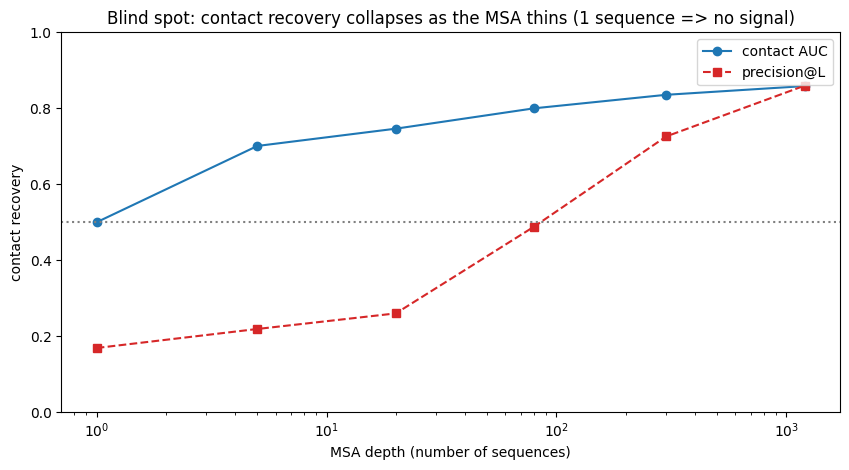

  MSA depth     1: contact AUC=0.500   precision@L=0.169
  MSA depth     5: contact AUC=0.701   precision@L=0.219
  MSA depth    20: contact AUC=0.746   precision@L=0.260
  MSA depth    80: contact AUC=0.800   precision@L=0.489
  MSA depth   300: contact AUC=0.836   precision@L=0.726
  MSA depth  1200: contact AUC=0.858   precision@L=0.860

At depth 1 the AUC sits at chance: a lone sequence has no co-evolution to read. Deep MSAs
are the oxygen of this method — remove them and the whole pipeline suffocates.


In [7]:
# Cell 7 — THE BLIND SPOT: no evolution, no structure (MSA depth controls everything)
# Reasoning: the worldview REQUIRES an informative MSA — co-evolution needs many sequences to be
# estimable. We sweep MSA depth N from a single sequence up to deep, regenerate each protein's MSA
# at that depth, and measure contact AUC + reconstruction RMSD. Recovery collapses as the alignment
# thins; a SINGLE sequence carries NO co-evolution signal at all (AUC ~0.5). This is precisely why
# orphan proteins defeated MSA-based methods — and why single-sequence protein language models
# (ESMFold), which LEARN evolutionary statistics implicitly (the transformer worldview, Notebook 06),
# were the next step in the lineage.

depths = [1, 5, 20, 80, 300, 1200]
seeds_used = [0, 1, 2, 3]                       # average over a few proteins for a stable curve
auc_by_depth, precL_by_depth = [], []
for Nd in depths:
    aucs, precs = [], []
    for sd in seeds_used:
        d = make_protein(sd, N=max(Nd, 1)); L = d["L"]; iu = np.triu_indices(L, 3)
        apc = np.nan_to_num(dca_apc(d["S"], L), nan=0.0, posinf=0.0, neginf=0.0)
        try:
            aucs.append(roc_auc_score(d["contact"][iu].astype(int), apc[iu]))
        except ValueError:
            aucs.append(0.5)
        o = np.argsort(apc[iu])[::-1][:L]; precs.append(d["contact"][iu][o].mean())   # precision@L
    auc_by_depth.append(np.mean(aucs)); precL_by_depth.append(np.mean(precs))

fig, ax1 = plt.subplots(figsize=(8.6, 4.8))
ax1.semilogx(depths, auc_by_depth, "o-", color="#1f77b4", label="contact AUC")
ax1.semilogx(depths, precL_by_depth, "s--", color="#d62728", label="precision@L")
ax1.axhline(0.5, ls=":", color="gray")
ax1.set_xlabel("MSA depth (number of sequences)"); ax1.set_ylabel("contact recovery")
ax1.set_ylim(0, 1.0); ax1.legend()
plt.title("Blind spot: contact recovery collapses as the MSA thins (1 sequence => no signal)")
fig.tight_layout(); plt.show()
for Nd, a, p in zip(depths, auc_by_depth, precL_by_depth):
    print(f"  MSA depth {Nd:5d}: contact AUC={a:.3f}   precision@L={p:.3f}")
print("\nAt depth 1 the AUC sits at chance: a lone sequence has no co-evolution to read. Deep MSAs")
print("are the oxygen of this method — remove them and the whole pipeline suffocates.")


## Conclusions — what the results teach

- **Structure is recoverable from sequence variation.** With co-evolving synthetic MSAs, direct-coupling analysis recovered contact maps (AUC ≈ 0.83), a triangle-update network sharpened them (AUC ≈ 0.90), and a distance-geometry structure module rebuilt held-out folds to ≈ 1–1.5 Å-scale RMSD / lDDT ≈ 0.8 — **from sequence alone, graded against known ground truth.**
- **Triangle updates are the load-bearing idea, not just "a neural net."** The ablation isolated them: raw DCA → learned-but-pairwise → triangle-updated each added real, separable gains. Enforcing distance path-consistency (the triangle inequality) is a geometric prior expressed as relational message passing.
- **AlphaFold is a *composition* of the series' worldviews.** Evolutionary statistics (Notebook 02) supply the signal; all-pairs attention over a pair representation (Notebook 06) refines it; triangle/relational updates (Notebook 07) enforce geometry; a distance-geometry module adds a mechanistic prior; and confidence comes from self-consistency. No single inductive bias would suffice — the power is in the assembly.
- **The blind spot is evolutionary depth.** Thin the MSA and recovery collapses; a single orphan sequence carries no co-evolution at all. That limitation drove the next chapter — single-sequence protein language models (ESMFold) that *learn* evolutionary statistics implicitly.

## The thread of all eight notebooks
Each architecture is an assumption about what structure data has, and excels exactly when the data matches it: strings and edits (DP), a hidden stochastic process (HMM), a similarity geometry (SVM), tabular interactions (trees), translation-invariant motifs (CNN), learnable long-range dependencies (transformers), relational structure (GNN). **AlphaFold closes the series by showing the real frontier is not choosing one bias but *composing* several so each handles the part of the problem whose structure it matches** — which is exactly the design question you started with: how to combine architectures into one system.
